# 1. Imports

In [60]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Pipeline y preprocesado
from sklearn.base import BaseEstimator, TransformerMixin  # para transformers personalizados
from sklearn.pipeline import Pipeline                      # para encadenar pasos
from sklearn.compose import ColumnTransformer             # para aplicar transformaciones por columnas
from sklearn.model_selection import train_test_split      # para dividir los datos
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Modelos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Métricas
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,  # PR-AUC
    ConfusionMatrixDisplay,
    precision_recall_curve,
    fbeta_score
)

# Gráficos
import matplotlib.pyplot as plt

# 2. Carga

In [ ]:
data_path = '../data/diabetes_prediction_dataset.csv'
data = pd.read_csv(data_path)

print('filas antes de filtrar:', data.shape[0])

filas antes de filtrar: 100000


# 3. Filtrado de valores no plausibles y categorías irrelevantes

In [4]:
data = data[data['bmi'] < 65]
data = data[data['gender'] != 'Other']

print('Filas después de filtrar:', data.shape[0])

data.head()

Filas después de filtrar: 99935


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 3. Se definen los predictores y el target

In [5]:
X = data.drop(columns=['diabetes'])
y = data['diabetes']

In [7]:
data['smoking_history'].value_counts()

smoking_history
No Info        35800
never          35071
former          9346
current         9278
not current     6438
ever            4002
Name: count, dtype: int64

# 4. Split train/test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# 5. Transformers personalizados y encodings

In [29]:
class SmokingMerger(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['smoking_history'] = X['smoking_history'].astype(str).map({
            'No Info':     'Unknown',
            'never':       'Never',
            'former':      'Former',
            'current':     'Current',
            'not current': 'Former',
            'ever':        'Former'
        })
        return X

In [30]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['gender', 'smoking_history']),
], remainder='passthrough', verbose_feature_names_out=False)

# 6. Pipeline

In [31]:
pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor)
])

Se comprueba que funciona correctamente:

In [32]:
pipeline.fit(X_train, y_train)

X_train_transformed = pipeline.named_steps['preprocessor'].transform(
    pipeline.named_steps['smoking_merger'].transform(X_train)
)

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

pd.DataFrame(X_train_transformed, columns=feature_names).head()

,gender_Female,gender_Male,smoking_history_Current,smoking_history_Former,smoking_history_Never,smoking_history_Unknown,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,0.0,1.0,1.0,0.0,0.0,0.0,43.0,0.0,0.0,21.06,5.7,126.0
1,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,15.72,4.8,126.0
2,1.0,0.0,0.0,0.0,1.0,0.0,48.0,1.0,0.0,27.32,6.0,155.0
3,0.0,1.0,0.0,0.0,1.0,0.0,20.0,0.0,0.0,24.60,6.2,200.0
4,1.0,0.0,0.0,0.0,1.0,0.0,29.0,0.0,0.0,27.17,6.5,200.0


# 7. Random Forest

Se definen los hiperparámetros:

In [63]:


rf_params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_split': [2, 10, 15, 20],
    'model__min_samples_leaf': [ 5, 10, 15, 20],
    'model__max_samples': [None, 0.7, 0.8],
    'model__ccp_alpha': [0.0, 0.001, 0.01]
}

Se aplica el pipeline: 

In [64]:

rf_pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
        criterion='gini'
    ))
])


Se configura el RandomizedSearchCV:

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Entrenamiento: 

In [66]:
rf_search.fit(X_train, y_train)
print('Mejores parámetros:', rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\dmoya\grupo_1\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Mejores parámetros: {'model__n_estimators': 300, 'model__min_samples_split': 15, 'model__min_samples_leaf': 20, 'model__max_samples': 0.7, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__ccp_alpha': 0.0}


Resultados por fold. Muestra las 10 mejores combinaciones de hiperparámetros ordenadas por PR-AUC medio descendente:

In [67]:
results = pd.DataFrame(rf_search.cv_results_)
results[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__max_features',
    'param_model__min_samples_split',
    'param_model__min_samples_leaf',
    'param_model__max_samples',
    'param_model__ccp_alpha',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('mean_test_score', ascending=False).head(3)

,param_model__n_estimators,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_samples,param_model__ccp_alpha,mean_test_score,std_test_score,rank_test_score
29,300,15,log2,15,20,0.7,0.0,0.880030,0.005381,1
22,100,20,sqrt,2,15,None,0.0,0.879919,0.005413,2
15,200,None,sqrt,10,10,0.8,0.0,0.879782,0.005661,3


Evaluacion final train/test:

=== TRAIN ===
Recall:    0.9237
Precision: 0.5238
PR-AUC:    0.9044

=== TEST ===
Recall:    0.9034
Precision: 0.5207
PR-AUC:    0.8833


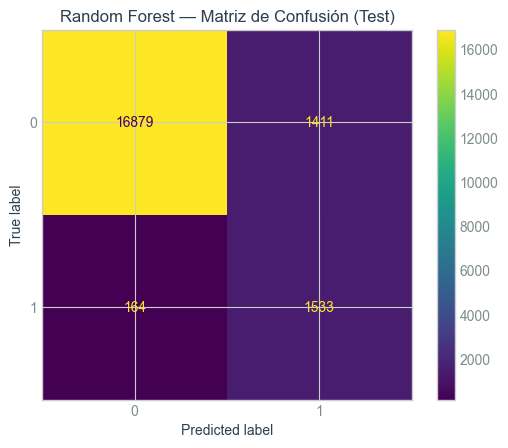

In [68]:
# Train
y_pred_train = rf_search.predict(X_train)
y_prob_train = rf_search.predict_proba(X_train)[:, 1]

# Test
y_pred_test = rf_search.predict(X_test)
y_prob_test = rf_search.predict_proba(X_test)[:, 1]

print("=== TRAIN ===")
print(f"Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"PR-AUC:    {average_precision_score(y_train, y_prob_train):.4f}")

print("\n=== TEST ===")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title('Random Forest — Matriz de Confusión (Test)')
plt.show()

# 8. Random Forest - Optimización del umbral de clasificación

In [69]:

# Probar todos los umbrales posibles
thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_test >= threshold).astype(int)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2)
    f2_scores.append(f2)

# Umbral óptimo
best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Umbral óptimo: {best_threshold:.2f}')
print(f'F2 máximo: {max(f2_scores):.4f}')

Umbral óptimo: 0.55
F2 máximo: 0.7904


=== TEST CON UMBRAL ÓPTIMO ===
Umbral F2:    0.55
Recall:    0.8786
Precision: 0.5639
PR-AUC:    0.8833


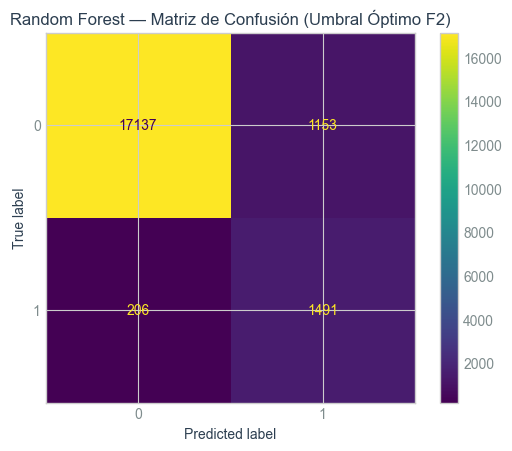

In [70]:
y_pred_optimal = (y_prob_test >= best_threshold).astype(int)

print("=== TEST CON UMBRAL ÓPTIMO ===")
print(f"Umbral F2:    {best_threshold:.2f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal)
plt.title('Random Forest — Matriz de Confusión (Umbral Óptimo F2)')
plt.show()